<a href="https://colab.research.google.com/github/dorhoffman/SWINGPULSE/blob/main/04_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import pandas as pd
import numpy as np

PROJECT_PATH = "/content/drive/MyDrive/SWINGPULSE"

FEATURES_PATH = (
    f"{PROJECT_PATH}/data/features/"
    "SWINGPULSE_FEATURES_DATASET.csv"
)

MODELS_FOLDER = f"{PROJECT_PATH}/models"

os.makedirs(MODELS_FOLDER, exist_ok=True)

print("Features file exists:", os.path.exists(FEATURES_PATH))
print("Models folder:", MODELS_FOLDER)

Mounted at /content/drive
Features file exists: True
Models folder: /content/drive/MyDrive/SWINGPULSE/models


In [2]:
sample = pd.read_csv(
    FEATURES_PATH,
    nrows=5
)

print(sample.columns.tolist())
display(sample)

['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Daily_Return', 'Volume_Change', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20', 'EMA_50', 'EMA_200', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'ATR_14', 'Volatility_20', 'Price_to_SMA20', 'Price_to_SMA50', 'Price_to_EMA20', 'EMA20_to_EMA50']


,Date,Symbol,Open,High,Low,Close,Volume,Dividends,Stock_Splits,Daily_Return,...,BB_Middle,BB_Upper,BB_Lower,BB_Width,ATR_14,Volatility_20,Price_to_SMA20,Price_to_SMA50,Price_to_EMA20,EMA20_to_EMA50
0,1999-11-18 05:00:00,A,27.708214,30.448590,24.358870,26.794758,62546380,0.0,0.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
1,1999-11-19 05:00:00,A,26.147735,26.185797,24.244699,24.587246,15234146,0.0,0.0,-0.082386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.924871,0.995370
2,1999-11-22 05:00:00,A,25.158145,26.794758,24.396931,26.794758,6577870,0.0,0.0,0.089783,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.007150,0.995993
3,1999-11-23 05:00:00,A,25.881299,26.566393,24.358870,24.358870,5975611,0.0,0.0,-0.090909,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.923011,0.991410
4,1999-11-24 05:00:00,A,24.435000,25.538762,24.358877,25.005911,4843231,0.0,0.0,0.026563,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.952287,0.988806


In [3]:
PREDICTION_HORIZON = 10
TARGET_RETURN = 0.10

print(
    f"Model objective: predict a rise of at least "
    f"{TARGET_RETURN * 100:.0f}% within "
    f"{PREDICTION_HORIZON} trading days."
)

Model objective: predict a rise of at least 10% within 10 trading days.


In [5]:
sample = pd.read_csv(
    FEATURES_PATH,
    nrows=5
)

print(sample.columns.tolist())

['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'Volume', 'Dividends', 'Stock_Splits', 'Daily_Return', 'Volume_Change', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_20', 'EMA_50', 'EMA_200', 'RSI_14', 'MACD', 'MACD_Signal', 'MACD_Histogram', 'BB_Middle', 'BB_Upper', 'BB_Lower', 'BB_Width', 'ATR_14', 'Volatility_20', 'Price_to_SMA20', 'Price_to_SMA50', 'Price_to_EMA20', 'EMA20_to_EMA50']


In [6]:
FEATURE_COLUMNS = [
    "Daily_Return",
    "Volume_Change",
    "SMA_20",
    "SMA_50",
    "SMA_200",
    "EMA_20",
    "EMA_50",
    "EMA_200",
    "RSI_14",
    "MACD",
    "MACD_Signal",
    "MACD_Histogram",
    "BB_Width",
    "ATR_14",
    "Volatility_20",
    "Price_to_SMA20",
    "Price_to_SMA50",
    "Price_to_EMA20",
    "EMA20_to_EMA50"
]

columns_to_load = [
    "Date",
    "Symbol",
    "Close"
] + FEATURE_COLUMNS

features = pd.read_csv(
    FEATURES_PATH,
    usecols=columns_to_load,
    parse_dates=["Date"],
    low_memory=False
)

print("Dataset shape:", features.shape)
print("Number of features:", len(FEATURE_COLUMNS))
display(features.head())

Dataset shape: (3878687, 22)
Number of features: 19


,Date,Symbol,Close,Daily_Return,Volume_Change,SMA_20,SMA_50,SMA_200,EMA_20,EMA_50,...,MACD,MACD_Signal,MACD_Histogram,BB_Width,ATR_14,Volatility_20,Price_to_SMA20,Price_to_SMA50,Price_to_EMA20,EMA20_to_EMA50
0,1999-11-18 05:00:00,A,26.794758,NaN,NaN,NaN,NaN,NaN,26.794758,26.794758,...,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000
1,1999-11-19 05:00:00,A,24.587246,-0.082386,-0.756434,NaN,NaN,NaN,26.584519,26.708189,...,-0.176098,-0.035220,-0.140878,NaN,NaN,NaN,NaN,NaN,0.924871,0.995370
2,1999-11-22 05:00:00,A,26.794758,0.089783,-0.568215,NaN,NaN,NaN,26.604541,26.711584,...,-0.135962,-0.055368,-0.080594,NaN,NaN,NaN,NaN,NaN,1.007150,0.995993
3,1999-11-23 05:00:00,A,24.358870,-0.090909,-0.091558,NaN,NaN,NaN,26.390668,26.619320,...,-0.297282,-0.103751,-0.193531,NaN,NaN,NaN,NaN,NaN,0.923011,0.991410
4,1999-11-24 05:00:00,A,25.005911,0.026563,-0.189500,NaN,NaN,NaN,26.258786,26.556049,...,-0.368669,-0.156735,-0.211935,NaN,NaN,NaN,NaN,NaN,0.952287,0.988806


In [7]:
PREDICTION_HORIZON = 10
TARGET_RETURN = 0.10

features = (
    features
    .sort_values(["Symbol", "Date"])
    .reset_index(drop=True)
)

features["Future_Close"] = (
    features
    .groupby("Symbol")["Close"]
    .shift(-PREDICTION_HORIZON)
)

features["Future_Return"] = (
    features["Future_Close"] - features["Close"]
) / features["Close"]

In [8]:
features["Target"] = (
    features["Future_Return"] >= TARGET_RETURN
).astype("int8")

rows_before = len(features)

features = features.dropna(
    subset=["Future_Close", "Future_Return"]
).copy()

print(f"Rows before: {rows_before:,}")
print(f"Rows after:  {len(features):,}")

Rows before: 3,878,687
Rows after:  3,873,657


In [9]:
target_summary = pd.DataFrame({
    "Count": features["Target"].value_counts(),
    "Percentage": (
        features["Target"]
        .value_counts(normalize=True)
        .mul(100)
        .round(2)
    )
})

display(target_summary)

,Count,Percentage
Target,,
0,3631139,93.74
1,242518,6.26


In [10]:
model_data = features.dropna(
    subset=FEATURE_COLUMNS + ["Target"]
).copy()

print(f"Rows available for modeling: {len(model_data):,}")
print("\nMissing values:")
print(model_data[FEATURE_COLUMNS].isnull().sum())

Rows available for modeling: 3,768,981

Missing values:
Daily_Return      0
Volume_Change     0
SMA_20            0
SMA_50            0
SMA_200           0
EMA_20            0
EMA_50            0
EMA_200           0
RSI_14            0
MACD              0
MACD_Signal       0
MACD_Histogram    0
BB_Width          0
ATR_14            0
Volatility_20     0
Price_to_SMA20    0
Price_to_SMA50    0
Price_to_EMA20    0
EMA20_to_EMA50    0
dtype: int64


In [11]:
# כל תאריכי המסחר הייחודיים, לפי סדר כרונולוגי
unique_dates = np.sort(
    model_data["Date"].dropna().unique()
)

split_index = int(len(unique_dates) * 0.80)

TEST_START_DATE = unique_dates[split_index]

# מרווח של 10 ימי מסחר כדי שה-Target של ה-Train
# לא ישתמש במחירים השייכים לתקופת ה-Test
TRAIN_END_DATE = unique_dates[
    split_index - PREDICTION_HORIZON
]

train_data = model_data[
    model_data["Date"] <= TRAIN_END_DATE
].copy()

test_data = model_data[
    model_data["Date"] >= TEST_START_DATE
].copy()

print("Train end date:", TRAIN_END_DATE)
print("Test start date:", TEST_START_DATE)

print(f"\nTrain rows: {len(train_data):,}")
print(f"Test rows:  {len(test_data):,}")

print("\nTrain Target distribution:")
print(
    train_data["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nTest Target distribution:")
print(
    test_data["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Train end date: 2011-06-17T04:00:00.000000000
Test start date: 2011-07-01T04:00:00.000000000

Train rows: 2,291,384
Test rows:  1,473,606

Train Target distribution:
Target
0    92.87
1     7.13
Name: proportion, dtype: float64

Test Target distribution:
Target
0    95.51
1     4.49
Name: proportion, dtype: float64


In [12]:
MAX_TRAIN_ROWS = 500_000

if len(train_data) > MAX_TRAIN_ROWS:
    train_sample = train_data.sample(
        n=MAX_TRAIN_ROWS,
        random_state=42
    ).copy()
else:
    train_sample = train_data.copy()

print(f"Training sample rows: {len(train_sample):,}")

print("\nSample Target distribution:")
print(
    train_sample["Target"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Training sample rows: 500,000

Sample Target distribution:
Target
0    92.9
1     7.1
Name: proportion, dtype: float64


In [13]:
X_train = train_sample[FEATURE_COLUMNS]
y_train = train_sample["Target"]

X_test = test_data[FEATURE_COLUMNS]
y_test = test_data["Target"]

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (500000, 19)
X_test: (1473606, 19)
y_train: (500000,)
y_test: (1473606,)


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

import time

In [16]:
# החלפת אינסוף בערכים חסרים
model_data[FEATURE_COLUMNS] = (
    model_data[FEATURE_COLUMNS]
    .replace([np.inf, -np.inf], np.nan)
)

# בדיקה כמה ערכים לא תקינים יש
print("Infinity / NaN before cleaning:")
print(model_data[FEATURE_COLUMNS].isna().sum())

# הסרת שורות עם ערכים לא תקינים
rows_before = len(model_data)

model_data = model_data.dropna(
    subset=FEATURE_COLUMNS + ["Target"]
).copy()

rows_after = len(model_data)

print(f"\nRows before cleaning: {rows_before:,}")
print(f"Rows after cleaning:  {rows_after:,}")
print(f"Rows removed:         {rows_before - rows_after:,}")

Infinity / NaN before cleaning:
Daily_Return         0
Volume_Change     2280
SMA_20               0
SMA_50               0
SMA_200              0
EMA_20               0
EMA_50               0
EMA_200              0
RSI_14               0
MACD                 0
MACD_Signal          0
MACD_Histogram       0
BB_Width             0
ATR_14               0
Volatility_20        0
Price_to_SMA20       0
Price_to_SMA50       0
Price_to_EMA20       0
EMA20_to_EMA50       0
dtype: int64

Rows before cleaning: 3,768,981
Rows after cleaning:  3,766,701
Rows removed:         2,280


In [17]:
unique_dates = np.sort(
    model_data["Date"].dropna().unique()
)

split_index = int(len(unique_dates) * 0.80)

TEST_START_DATE = unique_dates[split_index]

TRAIN_END_DATE = unique_dates[
    split_index - PREDICTION_HORIZON
]

train_data = model_data[
    model_data["Date"] <= TRAIN_END_DATE
].copy()

test_data = model_data[
    model_data["Date"] >= TEST_START_DATE
].copy()

In [18]:
MAX_TRAIN_ROWS = 500_000

if len(train_data) > MAX_TRAIN_ROWS:
    train_sample = train_data.sample(
        n=MAX_TRAIN_ROWS,
        random_state=42
    ).copy()
else:
    train_sample = train_data.copy()

X_train = train_sample[FEATURE_COLUMNS]
y_train = train_sample["Target"]

X_test = test_data[FEATURE_COLUMNS]
y_test = test_data["Target"]

In [19]:
print("Train infinity values:")
print(np.isinf(X_train.to_numpy()).sum())

print("Test infinity values:")
print(np.isinf(X_test.to_numpy()).sum())

print("Train NaN values:")
print(X_train.isna().sum().sum())

print("Test NaN values:")
print(X_test.isna().sum().sum())

Train infinity values:
0
Test infinity values:
0
Train NaN values:
0
Test NaN values:
0


In [20]:
logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            solver="lbfgs",
            random_state=42
        )
    )
])

start_time = time.time()

logistic_model.fit(
    X_train,
    y_train
)

logistic_training_time = time.time() - start_time

print(
    f"Logistic Regression training time: "
    f"{logistic_training_time:.2f} seconds"
)

Logistic Regression training time: 6.06 seconds


In [21]:
logistic_predictions = logistic_model.predict(
    X_test
)

logistic_probabilities = logistic_model.predict_proba(
    X_test
)[:, 1]

logistic_results = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(
        y_test,
        logistic_predictions
    ),
    "Precision": precision_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        logistic_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        logistic_probabilities
    ),
    "PR_AUC": average_precision_score(
        y_test,
        logistic_probabilities
    )
}

display(pd.DataFrame([logistic_results]))

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        logistic_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.86084,0.148698,0.44487,0.222893,0.752634,0.16053


Confusion Matrix:
[[1238955  168345]
 [  36693   29405]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.88      0.92   1407300
           1       0.15      0.44      0.22     66098

    accuracy                           0.86   1473398
   macro avg       0.56      0.66      0.57   1473398
weighted avg       0.93      0.86      0.89   1473398



In [22]:
random_forest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=14,
    min_samples_leaf=10,
    max_features="sqrt",
    class_weight="balanced_subsample",
    n_jobs=-1,
    random_state=42
)

start_time = time.time()

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_training_time = time.time() - start_time

print(
    f"Random Forest training time: "
    f"{random_forest_training_time:.2f} seconds"
)

Random Forest training time: 631.74 seconds


In [24]:
rf_predictions = random_forest_model.predict(
    X_test
)

rf_probabilities = random_forest_model.predict_proba(
    X_test
)[:, 1]

rf_results = {
    "Model": "Random Forest",
    "Accuracy": accuracy_score(
        y_test,
        rf_predictions
    ),
    "Precision": precision_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "Recall": recall_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "F1": f1_score(
        y_test,
        rf_predictions,
        zero_division=0
    ),
    "ROC_AUC": roc_auc_score(
        y_test,
        rf_probabilities
    ),
    "PR_AUC": average_precision_score(
        y_test,
        rf_probabilities
    )
}

display(pd.DataFrame([rf_results]))

print("Confusion Matrix:")
print(
    confusion_matrix(
        y_test,
        rf_predictions
    )
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        zero_division=0
    )
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Random Forest,0.912956,0.18966,0.287331,0.228496,0.772166,0.154924


Confusion Matrix:
[[1326155   81145]
 [  47106   18992]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.95   1407300
           1       0.19      0.29      0.23     66098

    accuracy                           0.91   1473398
   macro avg       0.58      0.61      0.59   1473398
weighted avg       0.93      0.91      0.92   1473398



In [25]:
model_comparison = pd.DataFrame([
    logistic_results,
    rf_results
])

model_comparison = model_comparison.sort_values(
    by="PR_AUC",
    ascending=False
).reset_index(drop=True)

display(
    model_comparison.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}",
        "ROC_AUC": "{:.4f}",
        "PR_AUC": "{:.4f}"
    })
)

,Model,Accuracy,Precision,Recall,F1,ROC_AUC,PR_AUC
0,Logistic Regression,0.8608,0.1487,0.4449,0.2229,0.7526,0.1605
1,Random Forest,0.9130,0.1897,0.2873,0.2285,0.7722,0.1549


In [26]:
feature_importance = pd.DataFrame({
    "Feature": FEATURE_COLUMNS,
    "Importance": random_forest_model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

display(feature_importance)

,Feature,Importance
14,Volatility_20,0.297304
12,BB_Width,0.126500
18,EMA20_to_EMA50,0.072121
16,Price_to_SMA50,0.049260
17,Price_to_EMA20,0.046140
8,RSI_14,0.043582
15,Price_to_SMA20,0.042250
0,Daily_Return,0.040646
13,ATR_14,0.036405
11,MACD_Histogram,0.026653


In [28]:
import matplotlib.pyplot as plt

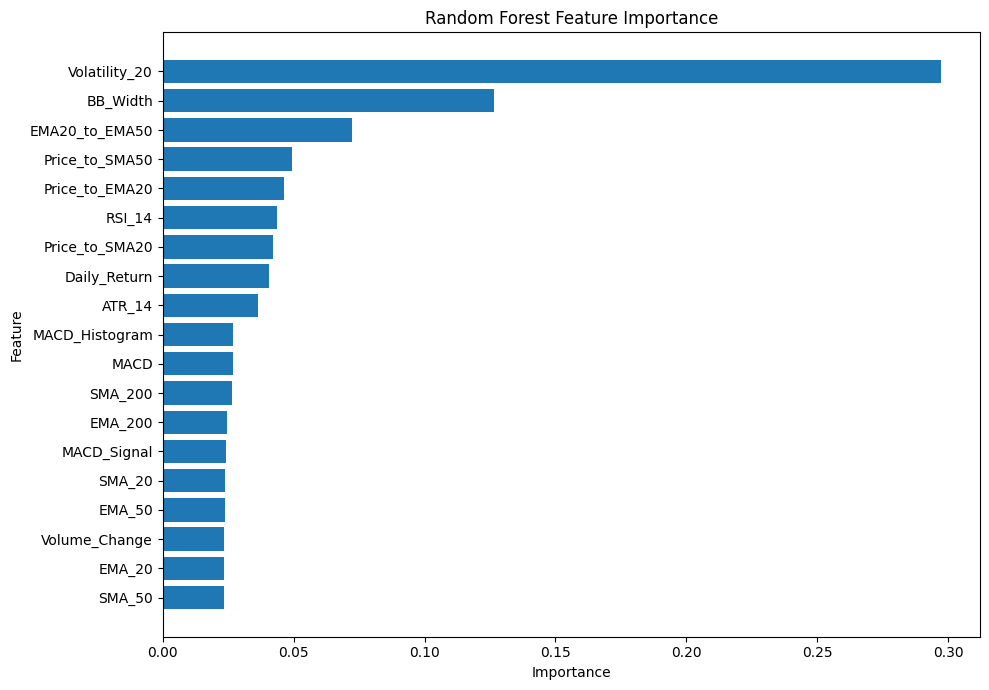

In [29]:
plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [30]:
import joblib
import json

LOGISTIC_PATH = (
    f"{MODELS_FOLDER}/"
    "logistic_regression_model.joblib"
)

RANDOM_FOREST_PATH = (
    f"{MODELS_FOLDER}/"
    "random_forest_model.joblib"
)

joblib.dump(
    logistic_model,
    LOGISTIC_PATH
)

joblib.dump(
    random_forest_model,
    RANDOM_FOREST_PATH
)

model_metadata = {
    "prediction_horizon": PREDICTION_HORIZON,
    "target_return": TARGET_RETURN,
    "features": FEATURE_COLUMNS,
    "train_end_date": str(TRAIN_END_DATE),
    "test_start_date": str(TEST_START_DATE),
    "train_sample_rows": len(train_sample),
    "test_rows": len(test_data)
}

METADATA_PATH = (
    f"{MODELS_FOLDER}/model_metadata.json"
)

with open(
    METADATA_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_metadata,
        file,
        indent=4
    )

print("Models saved successfully:")
print(LOGISTIC_PATH)
print(RANDOM_FOREST_PATH)
print(METADATA_PATH)

Models saved successfully:
/content/drive/MyDrive/SWINGPULSE/models/logistic_regression_model.joblib
/content/drive/MyDrive/SWINGPULSE/models/random_forest_model.joblib
/content/drive/MyDrive/SWINGPULSE/models/model_metadata.json
